# Coverage on a panel: what the one number hides

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/firefly1248/demo-notebooks/blob/main/notebooks/panel_coverage_by_gap.ipynb)

Companion notebook to part 12 of the series on predictive modelling with panel data.

A 90% prediction interval is usually checked with one number, the share of held-out rows it covers.
On a panel that number is an average: over how far each scored row is from its unit's last training
row, and over whichever rows were held out to compute it. This notebook fits one model and builds one
kind of interval, split conformal, then changes only the rows it is calibrated on, and reads coverage
in total and by gap.

In [1]:
import importlib.util
if importlib.util.find_spec("lightgbm") is None:
    !pip install -q lightgbm==4.7.0 matplotlib

In [2]:
import time
import numpy as np, pandas as pd, lightgbm as lgb
from scipy.optimize import minimize

pd.set_option("display.width", 250, "display.max_columns", 60)
print("lightgbm", lgb.__version__)

lightgbm 4.7.0


## The panel

Part 8's panel with its path memory switched off, which leaves part 6's truth. `NG` units are
observed over a window of `T_WIN`, rows arrive as a Poisson process at rate `LAM`, and `T_CUT` splits
time: rows before it can be trained on, rows after it are scored.

    y = g(x) + u(t) + noise

`g(x)` is a nonlinear function of two covariates, and `u(t)` is each unit's level drifting as an
Ornstein-Uhlenbeck process, covariance `SU**2 * exp(-|t - t'| / RHO)`. The random draws are made in
the same order as in part 8, so seed for seed these are the panels scored there.

In [3]:
NG, T_WIN, T_CUT, LAM, H = 480, 12.0, 8.0, 2.0, 0.05
SU, SE, RHO, RHO_X = 1.0, 0.5, 4.0, 1.0   # sd of the unit level, sd of the noise, their ranges
NSEED, M, K_FOLDS = 5, 300, 4
ALPHA = 0.10                              # a 90% interval
NEW, CAL = 0.2, 0.2                       # share of units kept as new units, share calibrated on
INNER = T_CUT - (T_WIN - T_CUT)           # the backtest cut, as far before T_CUT as T_CUT is from the end
GRID = np.arange(H, T_WIN + 1e-9, H)
NT = len(GRID)
FEAT = ["x1", "x2"]
BASE = {"objective": "regression_l2", "learning_rate": 0.05, "num_leaves": 31,
        "min_data_in_leaf": 20, "num_threads": 1, "verbose": -1}


def band(s):
    return f"{s.mean():.3f} [{s.min():.3f}, {s.max():.3f}]"


# n independent Ornstein-Uhlenbeck paths on GRID, exactly, by the AR(1) recursion
def ou_paths(rng, n, var, rho):
    phi = np.exp(-H/rho)
    z = np.empty((n, NT))
    z[:, 0] = rng.normal(0, np.sqrt(var), n)
    e = rng.normal(0, np.sqrt(var*(1 - phi**2)), (n, NT))
    for j in range(1, NT):
        z[:, j] = phi*z[:, j-1] + e[:, j]
    return z


def gfun(x1, x2):
    return 1.2*np.sin(2.0*x1) + 0.8*x1*x2


def panel(seed):
    rng = np.random.default_rng(seed)
    X1, X2 = ou_paths(rng, NG, 1.0, RHO_X), ou_paths(rng, NG, 1.0, RHO_X)
    U = ou_paths(rng, NG, SU**2, RHO)
    E = rng.normal(0, SE, (NG, NT))
    i, j = np.nonzero(rng.uniform(size=(NG, NT)) < LAM*H)
    return pd.DataFrame({"unit": i, "t": GRID[j], "x1": X1[i, j], "x2": X2[i, j],
                         "y": (gfun(X1, X2) + U + E)[i, j]}).sort_values(["unit", "t"],
                                                                        ignore_index=True)


# for each row of `te`, the time since its unit's latest row in `tr` before it; NaN if there is none
def gap_to(tr, te):
    a = pd.concat([tr[["unit", "t"]].assign(src=1, i=-1),
                   te[["unit", "t"]].assign(src=0, i=np.arange(len(te)))]).sort_values(["unit", "t"])
    last = a.t.where(a.src == 1).groupby(a.unit.values).ffill()
    return (a.t - last)[a.src.values == 0].values[np.argsort(a.i.values[a.src.values == 0])]


PAN = [panel(s) for s in range(NSEED)]

## Which rows get scored

Every seed splits the units once. A fifth are new units: none of their rows is used for anything but
scoring, and they stand for customers the model has never seen. The rest are seen units, and their
rows after the cut are the main target, a known customer some time after their last training row.
That time is the gap.

The cell below compares it with the gaps the training rows themselves have, the time from one row of
a unit to the next.

In [4]:
d = PAN[0]
pre = d.t.values <= T_CUT
step = d.groupby("unit").t.diff().values[pre]
step = step[~np.isnan(step)]
tg = gap_to(d[pre], d[~pre])
print(f"seed 0: {len(d)} rows over {NG} units, {pre.sum()} before the cut and {(~pre).sum()} after")
print(f"  training rows, time since the unit's previous row: quartiles "
      f"{np.round(np.quantile(step, [0.25, 0.5, 0.75]), 2)}, 95th percentile {np.quantile(step, 0.95):.2f}")
print(f"  rows after the cut, time since the unit's last training row: quartiles "
      f"{np.round(np.nanquantile(tg, [0.25, 0.5, 0.75]), 2)}")
print(f"  {np.nanmean(tg > np.quantile(step, 0.95)):.0%} of the rows after the cut are further from "
      f"their last training row than 95% of training rows are from their previous one")

seed 0: 11542 rows over 480 units, 7736 before the cut and 3806 after
  training rows, time since the unit's previous row: quartiles [0.15 0.35 0.65], 95th percentile 1.35
  rows after the cut, time since the unit's last training row: quartiles [1.41 2.5  3.5 ]
  77% of the rows after the cut are further from their last training row than 95% of training rows are from their previous one


### Gap bins

Every table splits the scored rows by gap into six bins of equal count, fixed once from the rows after
the cut over all seeds. They are the bins part 8 used.

In [5]:
TG = np.concatenate([gap_to(p[p.t <= T_CUT], p[p.t > T_CUT]) for p in PAN])
TG = TG[~np.isnan(TG)]
# cut on the gaps of the rows being scored, never on the calibration rows; calibration rows are
# then assigned to these same edges by their own gap
GAPB = np.r_[0.0, pd.qcut(TG, 6, retbins=True)[1][1:-1], np.inf]
GAPL = ([f"<{GAPB[1]:.2f}"] + [f"{a:.2f}-{b:.2f}" for a, b in zip(GAPB[1:-2], GAPB[2:-1])]
        + [f">{GAPB[-2]:.2f}"])


def gbin(g):
    return pd.cut(g, GAPB, labels=GAPL)


print(dict(zip(GAPL, pd.Series(gbin(TG)).value_counts().sort_index().tolist())))

{'<1.10': 3222, '1.10-1.80': 3216, '1.80-2.45': 3048, '2.45-3.15': 3287, '3.15-3.80': 3086, '>3.80': 3112}


## The model and the interval

One model throughout, part 6's two stages: LightGBM for the mean, an exponential covariance fitted by
maximum likelihood to its out-of-fold residuals, then each unit's conditional mean and sd in closed
form. A unit with no training row gets the booster's prediction and the marginal sd. The model is
refitted whenever the rows it may train on change, and nothing else about it changes.

The interval is split conformal. Take rows the model was not trained on, compute a score on each, and
use the `1 - ALPHA` quantile of the scores, with the usual finite-sample correction, as the half-width.
Three scores:

- `constant`: the absolute residual, so one width for every row.
- `kernel-scaled`: the absolute residual over the kernel's sd, so the width follows that sd.
- `per gap bin`: the absolute residual with a separate quantile in each gap bin, which is conformal
  prediction split by group, the group being the gap.

The guarantee is that the interval covers `1 - ALPHA` of new rows *exchangeable with the calibration
rows*. Everything below is about that clause.

In [6]:
def folds(tr, seed):            # by unit, so a unit's own rows cannot fit its own level
    u = np.unique(tr.unit.values)
    return np.random.default_rng(seed).integers(0, K_FOLDS, len(u))[np.searchsorted(u, tr.unit.values)]


def pooled(tr):
    return lgb.train(BASE, lgb.Dataset(tr[FEAT].values, tr.y.values), num_boost_round=M)


def oof(tr, seed):
    fold = folds(tr, seed)
    p = np.empty(len(tr))
    for k in range(K_FOLDS):
        p[fold == k] = pooled(tr[fold != k]).predict(tr[fold == k][FEAT].values)
    return tr.y.values - p


def cov_nll(z, groups):
    s2, vu, rho = np.exp(z)
    tot = 0.0
    for D, r, n in groups:
        C = vu*np.exp(-D/rho)
        C.flat[::n + 1] += s2
        L = np.linalg.cholesky(C)
        a = np.linalg.solve(L, r)
        tot += 2*np.log(np.diag(L)).sum() + a @ a
    return tot


def fit_cov(tr, r):
    groups = []
    for i in tr.groupby("unit").indices.values():
        t = tr.t.values[i]
        groups.append((np.abs(t[:, None] - t[None, :]), r[i], len(i)))
    z = minimize(cov_nll, np.log([r.var()/3, 2*r.var()/3, T_WIN/4]), args=(groups,),
                 method="Nelder-Mead", options={"xatol": 1e-3, "fatol": 1e-3, "maxiter": 4000}).x
    return np.exp(z)


# the conditional mean and variance at the rows of `te`, per unit, given that unit's residuals in `tr`
def krige(tr, te, r, par, fx):
    s2, vu, rho = par
    idx = tr.groupby("unit").indices
    mu, var = np.array(fx, float), np.full(len(te), vu + s2)
    for ti in te.groupby("unit").indices.values():
        o = idx.get(te.unit.values[ti[0]])
        if o is None:                               # a unit with no training row: the prior
            continue
        a = tr.t.values[o]
        Cm = vu*np.exp(-np.abs(a[:, None] - a[None, :])/rho) + s2*np.eye(len(a))
        k = vu*np.exp(-np.abs(te.t.values[ti][:, None] - a[None, :])/rho)
        sol = np.linalg.solve(Cm, np.c_[k.T, r[o]])
        mu[ti] += sol[:, -1] @ k.T
        var[ti] -= np.einsum("ij,ij->i", k, sol[:, :-1].T)
    return mu, var


# fits the two stages on `tr`; returns a predictor of (mean, sd) and the out-of-fold residuals
def fit_mean(tr, seed):
    b, r = pooled(tr), oof(tr, seed)
    par = fit_cov(tr, r)
    def predict(te):
        mu, var = krige(tr, te, r, par, b.predict(te[FEAT].values))
        return mu, np.sqrt(var)
    return predict, r


# the conformal quantile of Angelopoulos and Bates (2022): the ceil((n + 1)(1 - ALPHA))-th smallest
# score. Below 9 rows at 90% that rank does not exist and no finite width carries the guarantee.
# np.quantile(e, k/n, method="higher") is not this: it returns rank k + 1.
def cq(e):
    n = len(e)
    k = int(np.ceil((n + 1)*(1 - ALPHA)))
    return np.inf if k > n else np.sort(e)[k - 1]

## Three ways to choose calibration rows

All three take rows before the cut from seen units, as they must, since the rows after it are what
gets scored.

- `random rows`: a random fifth of those rows, with the model refitted on the other four fifths. This
  is what a default train-test split does.
- `held-out units`: every row of a random fifth of the seen units, with the model refitted on the
  rest. The calibration rows have no history in the model, like new units.
- `backtest`: a second cut at `INNER`. The model is refitted on the rows before it and calibrated on
  the rows between the two cuts, so a calibration row is as far from its unit's last training row as a
  scored row will be.

The interval is then put on the model fitted to every training row, the one that gets deployed, so the
only thing that differs between the three is where the quantile came from.

In [7]:
SCHEMES = ("random rows", "held-out units", "backtest")


def calibration_rows(tr, scheme, rng):
    if scheme == "random rows":
        return rng.random(len(tr)) < CAL
    if scheme == "held-out units":
        return (rng.random(NG) < CAL)[tr.unit.values]
    # fit before INNER, calibrate between INNER and T_CUT, score after T_CUT. The calibration
    # window is T_CUT - INNER, the same length as the scoring horizon T_WIN - T_CUT.
    return tr.t.values > INNER


# the half-width each score gives at rows with kernel sd `sd_at` and gap bin `b_at`
def half_widths(e, sd, gb, sd_at, b_at):
    qb = pd.Series(e).groupby(gb, observed=True).apply(lambda x: cq(x.values))
    return {"constant": np.full(len(sd_at), cq(e)), "kernel-scaled": cq(e/sd)*sd_at,
            "per gap bin": qb.reindex(b_at).values}


t0 = time.time()
hits, cal_info, pool = [], [], []
for s, d in enumerate(PAN):
    rng = np.random.default_rng(1000 + s)
    new = (rng.random(NG) < NEW)[d.unit.values]
    pre = d.t.values <= T_CUT
    tr = d[pre & ~new]
    deploy, r_oof = fit_mean(tr, s)
    targets = []
    for name, te in (("seen units", d[~pre & ~new]), ("new units", d[~pre & new])):
        mu, sd = deploy(te)
        targets.append((name, te, np.abs(te.y.values - mu), sd, gbin(gap_to(tr, te))))
    for scheme in SCHEMES:
        m = calibration_rows(tr, scheme, rng)
        fit, cal = tr[~m], tr[m]
        # the backtest calibrates on one scoring horizon's worth of rows before the cut, and the
        # held-out scheme calibrates on units the fit never saw. Both are what the mask says, so
        # they are checked here rather than asserted from the constants that define them.
        if scheme == "backtest":
            assert cal.t.min() > INNER and cal.t.max() <= T_CUT
        if scheme == "held-out units":
            assert not np.isin(cal.unit.unique(), fit.unit.unique()).any()
        mu, sd = fit_mean(fit, s)[0](cal)
        e, gc = np.abs(cal.y.values - mu), gap_to(fit, cal)
        gb = gbin(gc)
        per_bin = (cal.assign(bin=gb).groupby("bin", observed=True)
                   .agg(n=("unit", "size"), u=("unit", "nunique")).reindex(GAPL, fill_value=0))
        cal_info.append({"seed": s, "calibration": scheme, "rows": len(cal),
                         "median gap": np.nanmedian(gc) if gb.notna().any() else np.nan,
                         **per_bin.n.rename(lambda b: f"n {b}"),
                         **per_bin.u.rename(lambda b: f"u {b}")})
        for name, te, e_t, sd_t, b_t in targets:
            for score, h in half_widths(e, sd, gb, sd_t, b_t).items():
                if np.isnan(h).all():
                    continue
                # a gap bin with no calibration rows has no width: left out, not counted as a miss
                hits.append(pd.DataFrame({"seed": s, "calibration": scheme, "score": score,
                                          "target": name, "unit": te.unit.values, "bin": b_t,
                                          "hit": np.where(np.isnan(h), np.nan, e_t <= h),
                                          "width": 2*h}))
    # what a new unit's residual looks like, for the last section
    pool.append((s, tr.unit.values, np.abs(r_oof), targets[1][2]))
HT = pd.concat(hits, ignore_index=True)
CN = pd.DataFrame(cal_info)
print(f"{time.time() - t0:.0f}s")

13s


## The one number

Coverage and mean width of the 90% interval, mean over seeds with the range across them in brackets.

In [8]:
PS = HT.groupby(["target", "calibration", "score", "seed"]).agg(coverage=("hit", "mean"),
                                                                  width=("width", "mean"))
print(PS.groupby(level=[0, 1, 2]).agg(band).to_string())

                                                     coverage                 width
target     calibration    score                                                    
new units  backtest       constant       0.872 [0.838, 0.902]  3.487 [3.380, 3.615]
                          kernel-scaled  0.897 [0.861, 0.921]  3.731 [3.637, 3.843]
           held-out units constant       0.917 [0.868, 0.938]  3.933 [3.851, 4.186]
                          kernel-scaled  0.922 [0.869, 0.945]  3.987 [3.889, 4.331]
           random rows    constant       0.737 [0.682, 0.801]  2.501 [2.417, 2.568]
                          kernel-scaled  0.896 [0.847, 0.925]  3.715 [3.670, 3.768]
seen units backtest       constant       0.906 [0.899, 0.917]  3.487 [3.380, 3.615]
                          kernel-scaled  0.890 [0.879, 0.905]  3.321 [3.253, 3.427]
                          per gap bin    0.908 [0.902, 0.919]  3.508 [3.410, 3.598]
           held-out units constant       0.942 [0.939, 0.951]  3.933 [3.851,

## What it averages over

The same coverage on the seen units, split by gap bin, and next to it what each calibration set is
made of: how many rows, how far a calibration row is from its unit's last row in the model that
predicted it, and how many calibration rows land in each gap bin. Held-out units have no such row, so
their gaps are empty.

In [9]:
SEEN = HT[HT.target == "seen units"]
BS = SEEN.groupby(["calibration", "score", "seed", "bin"], observed=True).hit.mean().unstack("bin")[GAPL]
CB = BS.groupby(level=[0, 1]).mean()
print("coverage on the seen units by gap bin, mean over seeds")
print(CB.round(3).to_string())
print()
print(f"median gap of the rows being scored: {np.median(TG):.2f}")
print("the calibration rows, mean over seeds")
NCOL, UCOL = [f"n {b}" for b in GAPL], [f"u {b}" for b in GAPL]
print(CN.groupby("calibration")[["rows", "median gap"] + NCOL].mean().round(2).to_string())
print()
print("a bin with fewer than 9 calibration rows has no finite 90% width, and an infinite one covers")
print("every row: that is what the 1.000 cells above are, not a well calibrated interval")

coverage on the seen units by gap bin, mean over seeds
bin                           <1.10  1.10-1.80  1.80-2.45  2.45-3.15  3.15-3.80  >3.80
calibration    score                                                                  
backtest       constant       0.955      0.925      0.902      0.895      0.884  0.873
               kernel-scaled  0.893      0.893      0.887      0.893      0.890  0.886
               per gap bin    0.907      0.914      0.910      0.906      0.905  0.902
held-out units constant       0.977      0.957      0.944      0.931      0.927  0.918
               kernel-scaled  0.911      0.916      0.914      0.913      0.915  0.912
random rows    constant       0.842      0.801      0.760      0.759      0.728  0.738
               kernel-scaled  0.891      0.892      0.885      0.893      0.889  0.884
               per gap bin    0.833      0.838      0.829      0.870      1.000  1.000

median gap of the rows being scored: 2.45
the calibration rows, mean over 

## The check on one panel

In practice there is one panel, not five seeds. The check is the table above for that panel, with an
interval on each bin's coverage that resamples whole units, because rows of one unit share its level
and are not independent draws.

In [10]:
B_REPS = 500


def unit_band(hit, b, W):
    out = []
    for lab in GAPL:
        k = np.asarray(b == lab)
        est = (W[:, k]*hit[k]).sum(1)/W[:, k].sum(1)
        out.append({"bin": lab, "rows": k.sum(), "coverage": hit[k].mean(), "se": est.std(),
                    "95% by unit": f"[{np.quantile(est, 0.025):.3f}, {np.quantile(est, 0.975):.3f}]"})
    return pd.DataFrame(out)


one = SEEN[(SEEN.seed == 0) & (SEEN.calibration == "backtest")]
# every score scores the same rows in the same order, so one set of unit weights serves all three
ui = np.unique(one[one.score == "constant"].unit.values, return_inverse=True)[1]
W = np.random.default_rng(0).poisson(1.0, (B_REPS, ui.max() + 1))[:, ui]
UB = {}
for score, q in one.groupby("score", sort=False):
    UB[score] = unit_band(q.hit.values, q.bin.values, W)
    print(f"seed 0, calibrated on the backtest, {score}: {q.hit.mean():.3f} in total")
    print(UB[score].round(3).to_string(index=False))
    print()

seed 0, calibrated on the backtest, constant: 0.900 in total
      bin  rows  coverage    se    95% by unit
    <1.10   528     0.956 0.009 [0.939, 0.973]
1.10-1.80   504     0.929 0.014 [0.901, 0.956]
1.80-2.45   460     0.891 0.015 [0.863, 0.921]
2.45-3.15   503     0.897 0.015 [0.866, 0.927]
3.15-3.80   529     0.862 0.019 [0.824, 0.897]
    >3.80   512     0.863 0.018 [0.828, 0.900]

seed 0, calibrated on the backtest, kernel-scaled: 0.887 in total
      bin  rows  coverage    se    95% by unit
    <1.10   528     0.903 0.014 [0.878, 0.930]
1.10-1.80   504     0.893 0.017 [0.859, 0.924]
1.80-2.45   460     0.883 0.016 [0.852, 0.915]
2.45-3.15   503     0.899 0.015 [0.867, 0.928]
3.15-3.80   529     0.868 0.018 [0.829, 0.902]
    >3.80   512     0.879 0.018 [0.847, 0.912]

seed 0, calibrated on the backtest, per gap bin: 0.902 in total
      bin  rows  coverage    se    95% by unit
    <1.10   528     0.945 0.010 [0.925, 0.965]
1.10-1.80   504     0.923 0.014 [0.894, 0.950]
1.80-2.4

### The bins that run out of calibration rows

The random split leaves almost nothing in the far bins, and below nine rows no finite width carries a
90% guarantee at all. Seed by seed, in the three farthest bins:

In [11]:
rr = SEEN[(SEEN.calibration == "random rows") & (SEEN.score == "per gap bin")]
cn = CN[CN.calibration == "random rows"].set_index("seed")
for lab in GAPL[-3:]:
    print(lab)
    q = rr[rr.bin == lab]
    for s in range(NSEED):
        n = int(cn.loc[s, f"n {lab}"])
        h = q[q.seed == s].hit
        if n < 9:
            print(f"  seed {s}: {n} calibration rows, width = inf (insufficient calibration data)")
        else:
            print(f"  seed {s}: {n} calibration rows, coverage {h.mean():.3f} over {len(h)} rows")

2.45-3.15
  seed 0: 8 calibration rows, width = inf (insufficient calibration data)
  seed 1: 10 calibration rows, coverage 0.449 over 503 rows
  seed 2: 5 calibration rows, width = inf (insufficient calibration data)
  seed 3: 16 calibration rows, coverage 0.900 over 498 rows
  seed 4: 6 calibration rows, width = inf (insufficient calibration data)
3.15-3.80
  seed 0: 1 calibration rows, width = inf (insufficient calibration data)
  seed 1: 7 calibration rows, width = inf (insufficient calibration data)
  seed 2: 0 calibration rows, width = inf (insufficient calibration data)
  seed 3: 5 calibration rows, width = inf (insufficient calibration data)
  seed 4: 4 calibration rows, width = inf (insufficient calibration data)
>3.80
  seed 0: 1 calibration rows, width = inf (insufficient calibration data)
  seed 1: 1 calibration rows, width = inf (insufficient calibration data)
  seed 2: 0 calibration rows, width = inf (insufficient calibration data)
  seed 3: 2 calibration rows, width = in

## How many calibration rows a unit is worth

The conformal quantile is estimated from the calibration rows, and its error depends on how many
independent draws they hold. Rows of one unit share its level, so they hold fewer than their count.

To measure that, the out-of-fold residuals of the seen units, which is what a unit with no history
looks like, are used as a calibration pool. They are drawn a thousand times per size, either as whole
units or as the same number of rows at random, and each time the coverage the quantile delivers on the
new units is read. The spread of that coverage is set against the one independent rows would give,
`sqrt(ALPHA * (1 - ALPHA) / (n + 2))`, and the number of independent rows the whole-unit spread is worth
is read off the same formula.

In [12]:
REPS, KS = 1000, (5, 10, 30, 100)
out = []
for s, unit, e, e_new in pool:
    rng = np.random.default_rng(s)
    uu = np.unique(unit)
    for k in KS:
        by_unit, by_row, n = [], [], []
        for _ in range(REPS):
            pick = np.isin(unit, rng.choice(uu, k, replace=False))
            n.append(pick.sum())
            by_unit.append(np.mean(e_new <= cq(e[pick])))
            by_row.append(np.mean(e_new <= cq(e[rng.choice(len(e), pick.sum(), replace=False)])))
        out.append({"seed": s, "units": k, "rows": np.mean(n),
                    "sd, whole units": np.std(by_unit), "sd, random rows": np.std(by_row),
                    "5th pct, whole units": np.quantile(by_unit, 0.05),
                    "5th pct, random rows": np.quantile(by_row, 0.05)})
UN = pd.DataFrame(out)
UN["sd, independent rows"] = np.sqrt(ALPHA*(1 - ALPHA)/(UN["rows"] + 2))
UN["worth, rows"] = ALPHA*(1 - ALPHA)/UN["sd, whole units"]**2 - 2
print(UN.drop(columns="seed").groupby("units").mean().round(3).to_string())

           rows  sd, whole units  sd, random rows  5th pct, whole units  5th pct, random rows  sd, independent rows  worth, rows
units                                                                                                                           
5        79.567            0.053            0.033                 0.805                 0.852                 0.033       32.559
10      158.872            0.039            0.024                 0.834                 0.864                 0.024       60.907
30      477.252            0.024            0.015                 0.863                 0.882                 0.014      164.733
100    1591.240            0.013            0.008                 0.884                 0.893                 0.008      609.442


## The figure

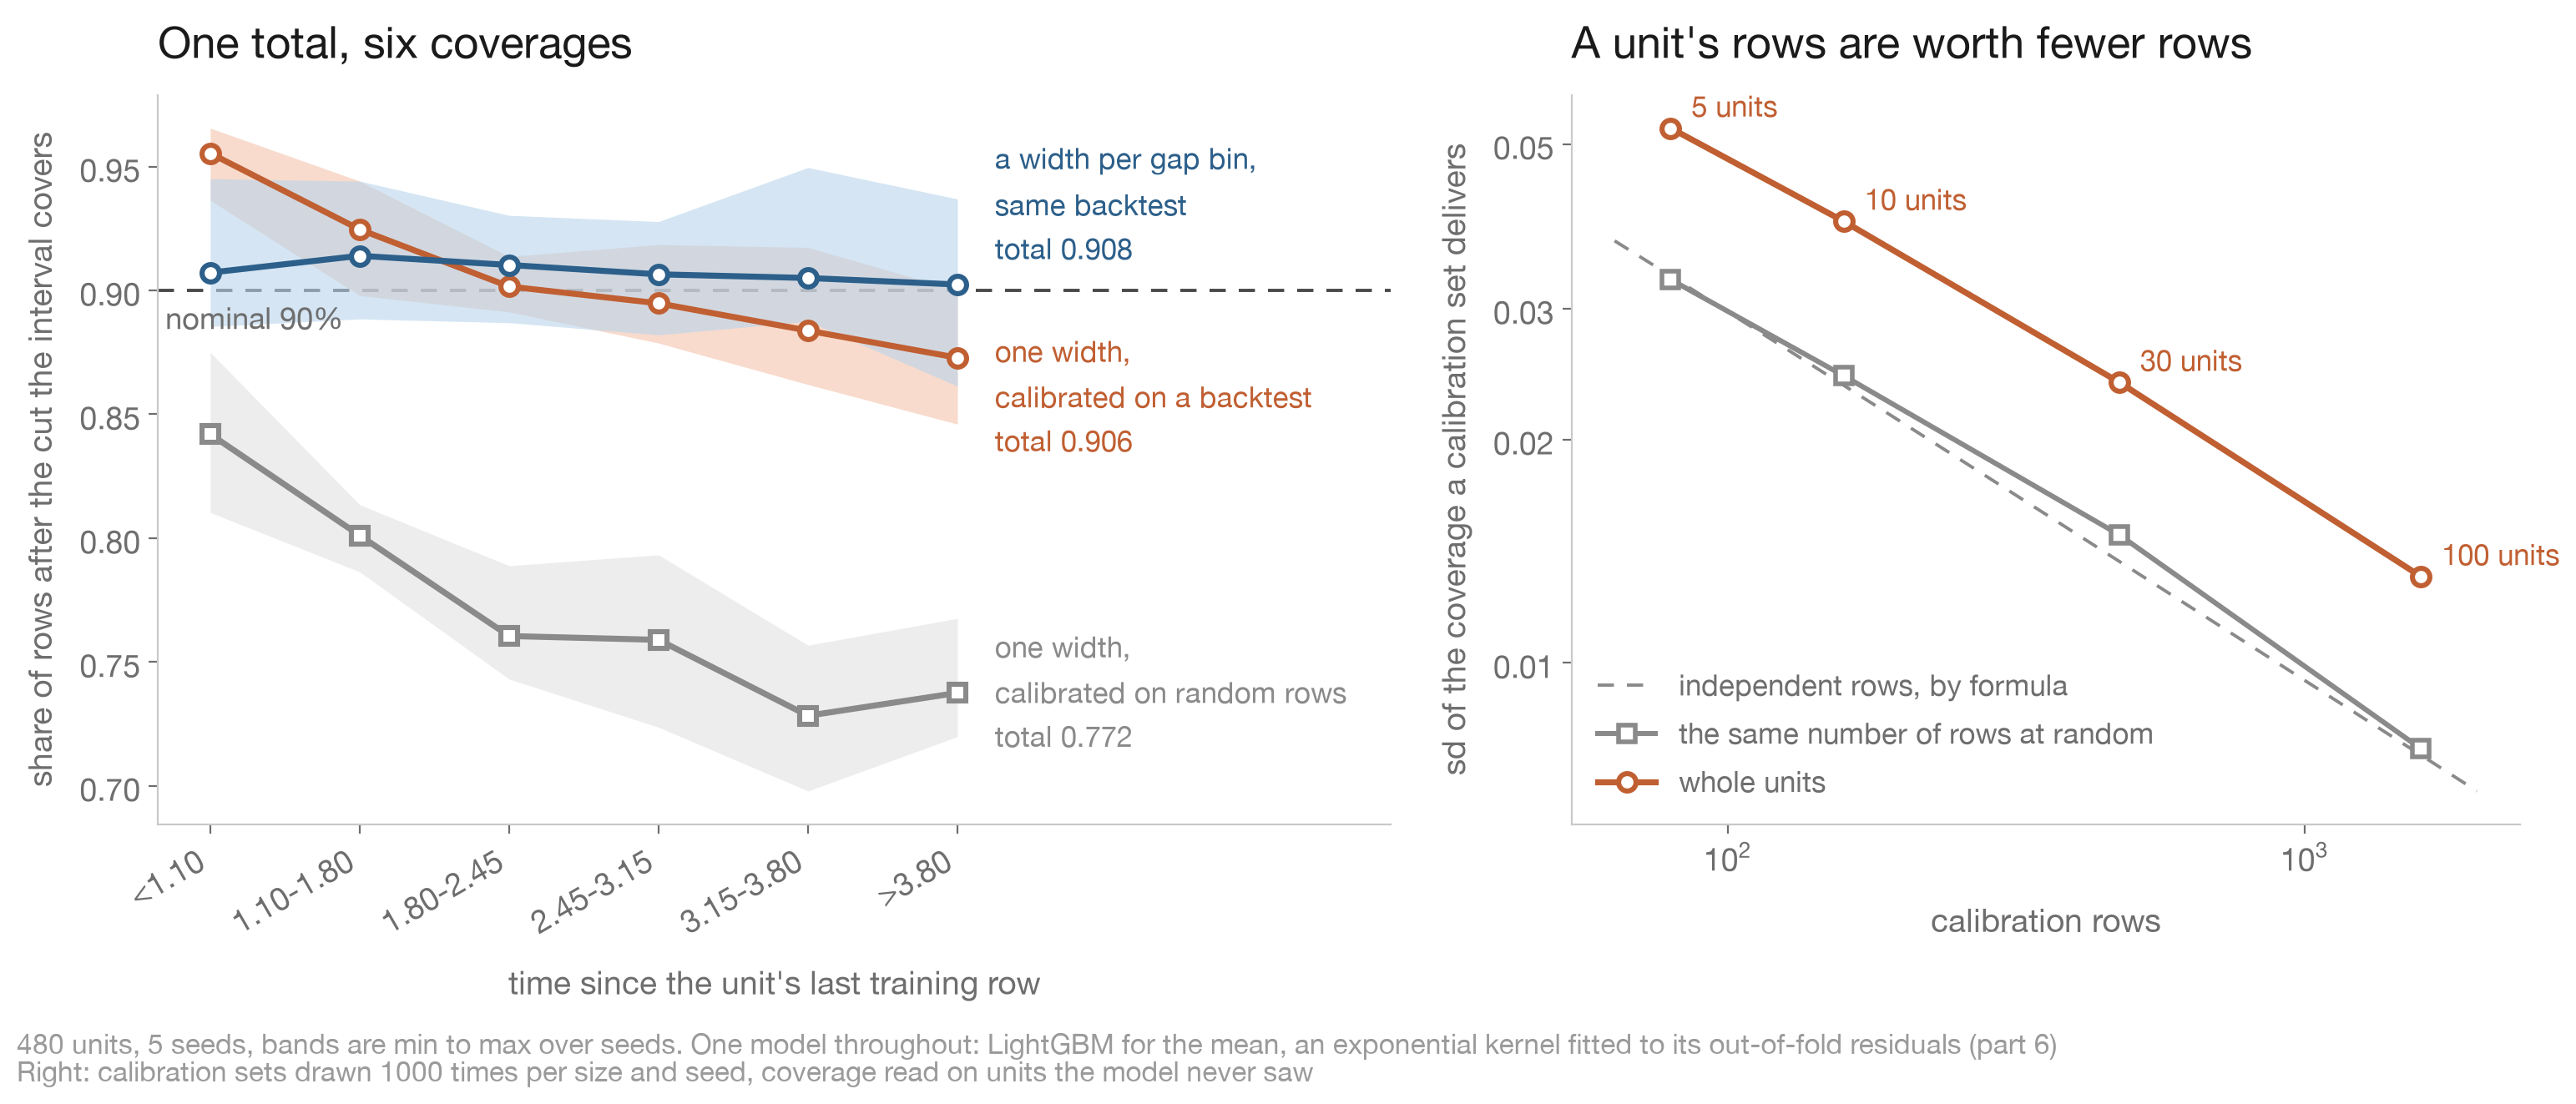

In [13]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]
BLUE_E, BLUE_F = "#2C5F8A", "#B9D5EC"
CORAL_E, CORAL_F = "#C05F32", "#F4C3AC"
GREY_E, GREY_F = "#8a8a8a", "#E2E2E2"
INK, MUTED, FAINT = "#1a1a1a", "#6e6e6e", "#9a9a9a"
LINES = [("random rows", "constant", GREY_E, GREY_F, "s", 0.0, "one width,\ncalibrated on random rows"),
         ("backtest", "constant", CORAL_E, CORAL_F, "o", -0.016, "one width,\ncalibrated on a backtest"),
         ("backtest", "per gap bin", BLUE_E, BLUE_F, "o", 0.032,"a width per gap bin,\nsame backtest")]
x = np.arange(len(GAPL))
OV = PS.loc["seen units", "coverage"].groupby(level=[0, 1]).mean()

fig, axes = plt.subplots(1, 2, figsize=(15.6, 6.6), dpi=200, gridspec_kw={"width_ratios": [1.3, 1]})
fig.patch.set_facecolor("white")

# left: coverage by gap bin, and the total each line reports
ax = axes[0]
for cal, sc, ec, fc, mk, dy, lab in LINES:
    d = BS.loc[(cal, sc)]
    ax.fill_between(x, d.min().values, d.max().values, color=fc, alpha=0.6, lw=0, zorder=2)
    ax.plot(x, d.mean().values, color=ec, lw=2.6, marker=mk, ms=7.5, mfc="white", mew=2.2, zorder=4)
    ax.text(x[-1] + 0.25, d.mean().values[-1] + dy, f"{lab}\ntotal {OV.loc[(cal, sc)]:.3f}",
            fontsize=12.5, color=ec, va="center", linespacing=1.3)
ax.axhline(1 - ALPHA, color="#4a4a4a", lw=1.4, ls=(0, (5, 4)), zorder=1)
ax.text(-0.3, 1 - ALPHA - 0.004, "nominal 90%", fontsize=13, color=MUTED, va="top")
ax.set_xticks(x)
ax.set_xticklabels(GAPL, rotation=30, ha="right")
ax.set_xlim(-0.35, len(GAPL) + 1.9)
ax.set_xlabel("time since the unit's last training row", fontsize=14, color=MUTED, labelpad=10)
ax.set_ylabel("share of rows after the cut the interval covers", fontsize=14, color=MUTED, labelpad=9)
ax.set_title("One total, six coverages", fontsize=19, color=INK, pad=16, loc="left")

# right: how much a calibration set of whole units varies, against the same count of rows
ax = axes[1]
u = UN.groupby("units").mean()
n = np.logspace(np.log10(u.rows.min()*0.8), np.log10(u.rows.max()*1.25), 100)
ax.plot(n, np.sqrt(ALPHA*(1 - ALPHA)/(n + 2)), color=GREY_E, lw=1.4, ls=(0, (5, 4)), zorder=1,
        label="independent rows, by formula")
ax.plot(u.rows, u["sd, random rows"], color=GREY_E, lw=2.2, marker="s", ms=7, mfc="white", mew=2,
        zorder=3, label="the same number of rows at random")
ax.plot(u.rows, u["sd, whole units"], color=CORAL_E, lw=2.6, marker="o", ms=7.5, mfc="white", mew=2.2,
        zorder=4, label="whole units")
for k, r in u.iterrows():
    ax.annotate(f"{k} units", (r.rows, r["sd, whole units"]), xytext=(9, 5),
                textcoords="offset points", fontsize=12.5, color=CORAL_E)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_yticks([0.01, 0.02, 0.03, 0.05], ["0.01", "0.02", "0.03", "0.05"])
ax.minorticks_off()
ax.legend(frameon=False, fontsize=12.5, loc="lower left", labelcolor=MUTED)
ax.set_xlabel("calibration rows", fontsize=14, color=MUTED, labelpad=10)
ax.set_ylabel("sd of the coverage a calibration set delivers", fontsize=14, color=MUTED, labelpad=9)
ax.set_title("A unit's rows are worth fewer rows", fontsize=19, color=INK, pad=16, loc="left")

for ax in axes:
    ax.tick_params(labelsize=13.5, colors=MUTED, length=4)
    ax.tick_params(which="minor", colors=MUTED)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color("#c9c9c9")

fig.text(0.008, 0.035, f"{NG} units, {NSEED} seeds, bands are min to max over seeds. One model throughout: "
         "LightGBM for the mean, an exponential kernel fitted to its out-of-fold residuals (part 6)",
         fontsize=12, color=FAINT, ha="left")
fig.text(0.008, 0.010, f"Right: calibration sets drawn {REPS} times per size and seed, coverage read on "
         "units the model never saw", fontsize=12, color=FAINT, ha="left")
fig.tight_layout(rect=[0, 0.06, 1, 1.0])
fig.savefig("panel_coverage_by_gap.png", facecolor="white")
plt.show()

## What this notebook measured

Split conformal delivered its nominal level only where the calibration rows looked like the rows being
scored. Calibrated on random training rows, the one-width interval under-covers every gap bin: those
rows sit between training rows of their own unit, a fraction of the deployment gap away, so their
residuals are small and so is the quantile. Calibrated on held-out units, it over-covers the seen
units, whose history the model does use. The backtest reproduces the deployment gap, and the
one-width interval built on it lands on its nominal level in total.

That total is an average. By gap bin the same interval over-covers the rows just after the cut and
under-covers the far ones, and the total sits on the nominal level because the two cancel over this
panel's mix of gaps. A different mix, the same interval, and a different total.

A width per gap bin holds the level in every bin. A width proportional to the kernel's sd is flat
across bins too, but sits a little under nominal. The per-bin version needs calibration rows in every bin, and the
random split has almost none in the far ones: below nine rows no finite width carries a 90%
guarantee, so those bins get an infinite width and cover everything, while a bin just above that
cutoff rests on so few rows that its coverage swings from seed to seed. The scaled version is the more forgiving: about as close to nominal on random rows as on the
backtest, because the sd already accounts for how far each row is from its unit's last one.

Rows of one unit share its level, so a calibration set holds fewer independent draws than rows. Drawn
as whole units, the coverage a calibration set delivers spreads well beyond what the same number of
independent rows would give. Count units, not rows, when deciding whether a calibration set is big
enough, and resample units when putting an interval on a coverage.

In [14]:
bt = CN[CN.calibration == "backtest"]
se = UB["constant"].se
print("=== Numbers for Part 12 ===")
print(f"Rows per bin (backtest, approx):      {bt[NCOL].mean().mean():.0f}")
print(f"Customers per bin (backtest, approx): {bt[UCOL].mean().mean():.0f}")
print(f"Bootstrap SE per bin (+/-):           {se.mean():.3f}  (range {se.min():.3f} to {se.max():.3f})")
print(f"Normalized conformal, random split:   "
      f"{PS.loc[('seen units', 'random rows', 'kernel-scaled'), 'coverage'].mean():.3f}")
print(f"Gap unit label (x-axis label used):   time since the unit's last training row, in the "
      f"simulation's own time units (window {T_WIN:g}, unit-level range {RHO:g})")

=== Numbers for Part 12 ===
Rows per bin (backtest, approx):      515
Customers per bin (backtest, approx): 278
Bootstrap SE per bin (+/-):           0.015  (range 0.009 to 0.019)
Normalized conformal, random split:   0.889
Gap unit label (x-axis label used):   time since the unit's last training row, in the simulation's own time units (window 12, unit-level range 4)
